In [6]:
####What Shape is the EEG DATA?

In [7]:
!pip install mne --break-system-packages

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import mne 
import os
import argparse
from glob import glob
from pathlib import Path


### Making a Dictionary to store patient all patient data 

In [3]:
path_to_directories= Path('/Users/kerrighanmilton/Documents/EEG Project')

def process_files_in_directory(argv):
    patient_data= {} #stores the shape of the data extracted from the .set files of each patient 
    complete_file_path=[]
    file_path_string= []
    
    for if_dir in argv['path_to_directories']:   
        for current_file,dirs,files in os.walk(if_dir):# collect paths here 
            dirs.sort() #.sort orders the directories here beforehand so the data appears in the right order
            if 'derivatives' in dirs: 
                
                dirs.remove('derivatives')
            for file in files:  
                if file.endswith('.set'): # process collected paths 
                    file_path= os.path.join(current_file,file)#creates a string; you cannot sort here
                    complete_file_path.append(file_path)
                    file_path_string.append(file_path.split('/'))
    for row_index, row in enumerate(file_path_string):
        subject_name = row[5]
        full_path = complete_file_path[row_index]
        raw = mne.io.read_raw_eeglab(full_path)  # reading the raw data stored within the file_path
        data = raw.get_data() #extracting the data in raw
        patient_data[subject_name] = raw  # creating the keys and values for the dictionary 

              
    return patient_data  # we want to know what the dictionary looks like everytime we call this function 


#this is your patient data for each patient 
patient_data_dict = process_files_in_directory({'path_to_directories': [path_to_directories]})
#print(len(patient_data_dict))
list(patient_data_dict.keys())[:5]





Reading /Users/kerrighanmilton/Documents/EEG Project/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-002/eeg/sub-002_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-003/eeg/sub-003_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-004/eeg/sub-004_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-005/eeg/sub-005_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-006/eeg/sub-006_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-007/eeg/sub-007_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-008/eeg/sub-008_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-009/eeg/sub-009_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton/Documents/EEG Project/sub-010/eeg/sub-010_task-eyesclosed_eeg.set
Reading /Users/kerrighanmilton

['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']

In [10]:
####Plot the patient data for one subject 

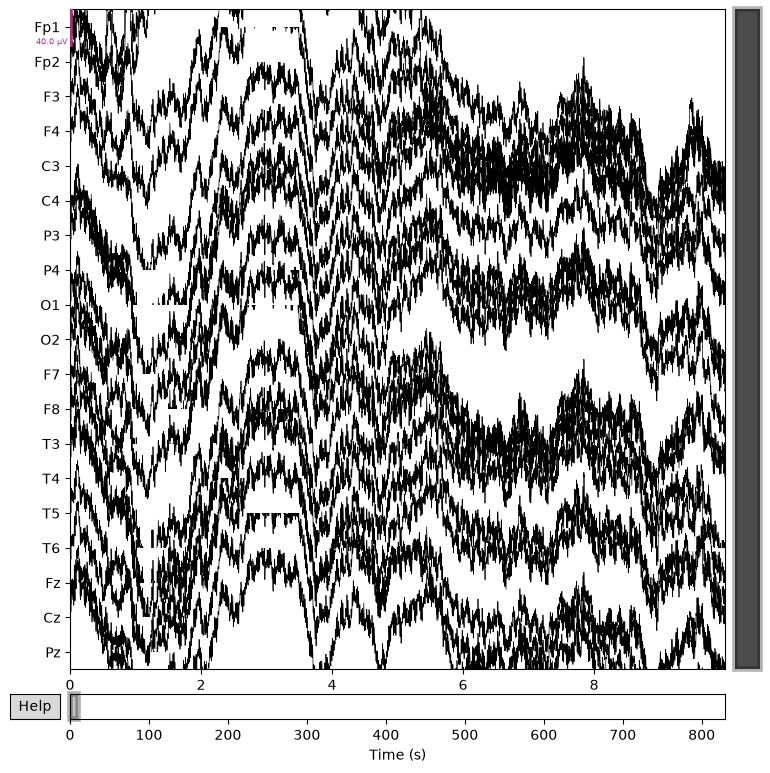

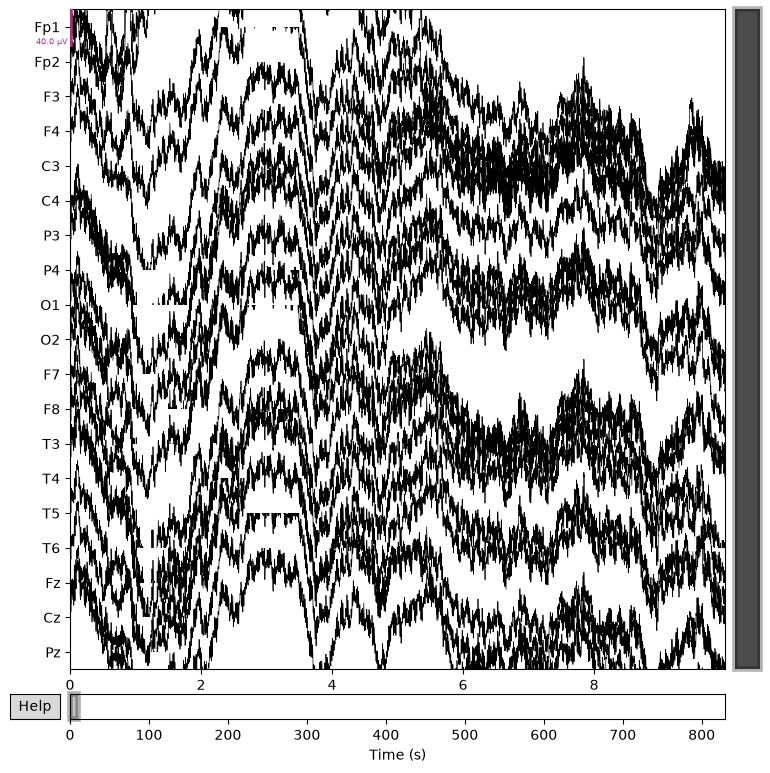

In [11]:
raw = result['sub-081'] # we can now plot all dictonary entries 
raw.plot()




# Whose Who? Alzheimer Patients vs Healthy Patients 




In [12]:
#load patinet tsv folder by first building a path to the folder 

In [13]:
paths_participants_in_study = '/Users/kerrighanmilton/Documents/EEG Project/participants.tsv'
labels = pd.read_csv(paths_participants_in_study, sep='\t')
print(labels)
print(labels.shape)

   participant_id Gender  Age Group  MMSE
0         sub-001      F   57     A    16
1         sub-002      F   78     A    22
2         sub-003      M   70     A    14
3         sub-004      F   67     A    20
4         sub-005      M   70     A    22
..            ...    ...  ...   ...   ...
83        sub-084      F   71     F    24
84        sub-085      M   64     F    26
85        sub-086      M   49     F    26
86        sub-087      M   73     F    24
87        sub-088      M   55     F    24

[88 rows x 5 columns]
(88, 5)


### We need to filter the data that is stored under each patient in the dictionary so we need to first make a copy of our library for filtering 

Reading 0 ... 299899  =      0.000 ...   599.798 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (6.602 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Using matplotlib as 2D backend.


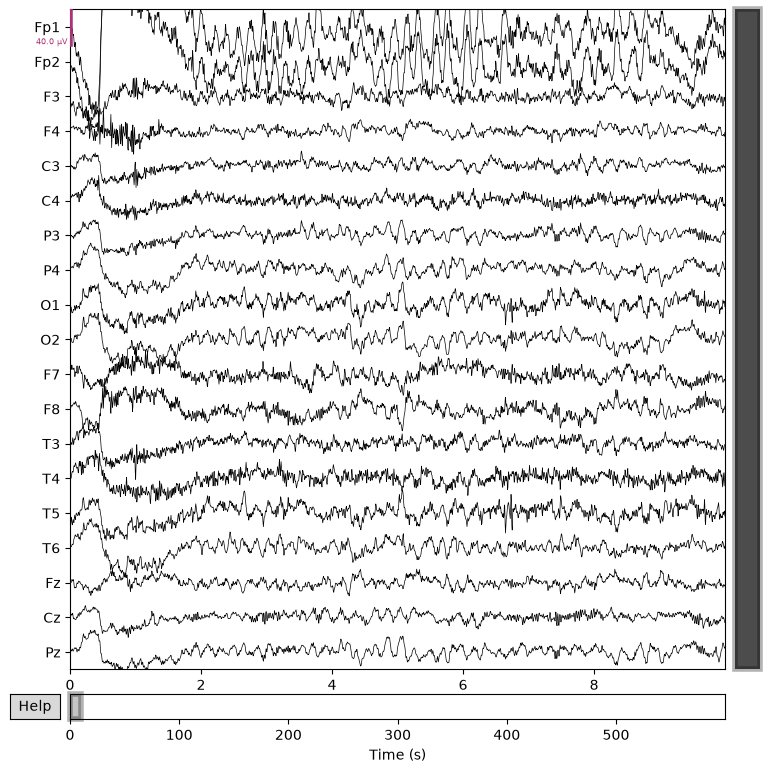

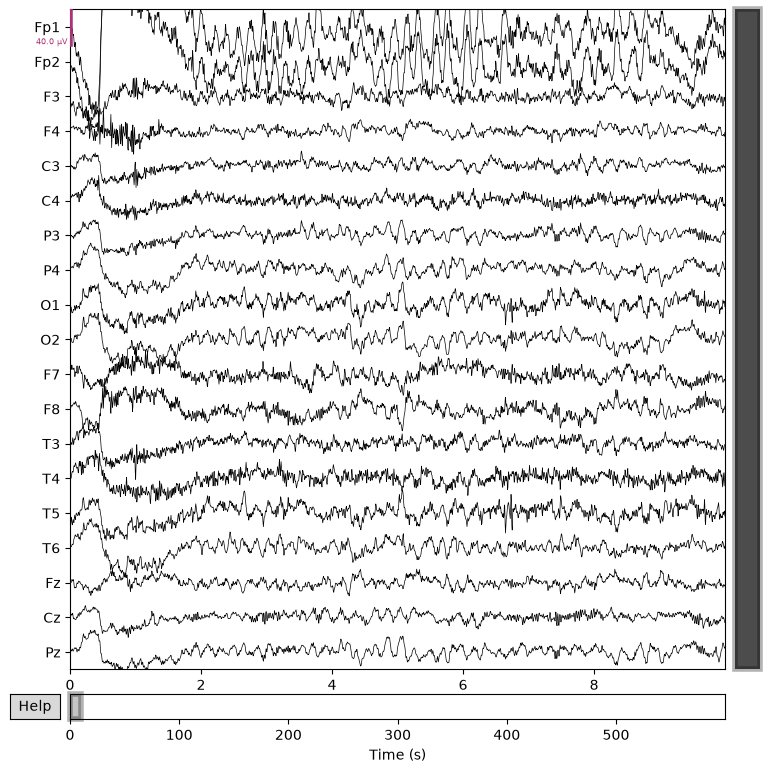

In [18]:
raw_to_filtered = patient_data_dict ['sub-001'].copy()
raw_to_filtered.load_data()
raw_to_filtered.filter(0.5,45) #: 0.5 clears slow drift, 45 clears muscle and stays under the 50 Hz line noise, and everything your Alzheimer's analysis cares about lives in between
raw_to_filtered.set_eeg_reference('average')
raw_to_filtered.plot()



In [19]:
#catching the epochs 
epochs = mne.make_fixed_length_epochs(raw_to_filtered,duration=4)
print(epochs.get_data().shape)
epochs.drop_bad(reject={'eeg': 150e-6}) # getting rid of blinks and signals with large distances 
print(epochs)

Not setting metadata
149 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 149 events and 2000 original time points ...
0 bad epochs dropped
(149, 19, 2000)
Using data from preloaded Raw for 149 events and 2000 original time points ...
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1']
    Rejecting  epoch based on EEG : ['Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2']
    R

### "sub-001 preprocessing COMPLETE (filter 0.5–45, avg ref, 4s epochs, reject 150e-6 → 132/149 kept). NEXT: spectral extraction — epochs.compute_psd(fmin=0.5, fmax=45), catch in spectrum, check the shape swaps time→frequency."


In [20]:
spectrum = epochs.compute_psd(fmin=0.5, fmax=45)
print(spectrum)
print(spectrum.get_data().shape)

Using data from preloaded Raw for 132 events and 2000 original time points ...
    Using multitaper spectrum estimation with 7 DPSS windows
<Power Spectrum (from Epochs, multitaper method) | 132 epochs × 19 channels × 179 freqs, 0.5-45.0 Hz>
(132, 19, 179)


So the corrected reading of the tuple: 132 windows × 19 channels × 179 frequency bins spanning the full 0.5–45 Hz range — and theta is a small sub-range we're about to carve out of that 179.

In [21]:
psds, freqs = spectrum.get_data(return_freqs=True)
print(psds.shape)
print(freqs.shape)
print(freqs.min(), freqs.max())

(132, 19, 179)
(179,)
0.5 45.0


In [18]:
### creating a boolean mask to find the frequencies that align with the theta frequency 

In [22]:
theta_mask = (freqs >= 4) & (freqs < 8)
print(freqs[theta_mask])

[4.   4.25 4.5  4.75 5.   5.25 5.5  5.75 6.   6.25 6.5  6.75 7.   7.25
 7.5  7.75]


### ### applying the mask to all the power densities of found in the patinet data  So a single number deep in there — psds[5, 10, 30] — reads as: "in epoch 5, at channel 10, the power at the 30th frequency bin." The number tells you how much signal energy sat at that frequency, in that channel, during that window.


In [23]:
applied_mask = psds[:,:,theta_mask]

print(applied_mask.shape) #theta power (132 epochs, 19channels, 16 theta frequency bins)


(132, 19, 16)


In [24]:
theta_power = applied_mask.mean(axis=2)
print(theta_power.shape)   
# 132 epochs, 19 channels, and becuase each channe now hods a single theta numner instead of 16 bins we have reduced the complexity

(132, 19)


### The array above is stripped of specificty when you used .get_data in line 10. the numpy array is numerical and bare while mne contains the specified data/ 

In [22]:
print(spectrum .ch_names[3]) #decoder ring to match array data to cranial position 
 

F4


In [23]:
theta_power[:,3] # theta power for all 132 epoch and each theta_power for F4 region of brain 

array([6.95105673e-10, 6.28522808e-10, 3.50952360e-10, 9.61911814e-10,
       6.51520790e-10, 2.99854603e-10, 9.50182073e-10, 6.89660991e-10,
       5.70882917e-10, 7.33026409e-10, 6.81459030e-10, 4.23163720e-10,
       6.63551268e-10, 5.69490739e-10, 4.42949505e-10, 4.81593119e-10,
       5.69228107e-10, 7.19585893e-10, 4.50144620e-10, 6.89612078e-10,
       9.45902916e-10, 4.92620046e-10, 6.68351246e-10, 4.72440938e-10,
       9.38518140e-10, 7.68729286e-10, 4.54581951e-10, 6.56134685e-10,
       5.38358453e-10, 1.31449642e-09, 3.13707126e-10, 6.02023387e-10,
       6.12453329e-10, 1.00240302e-09, 3.77605981e-10, 6.41507333e-10,
       4.19785194e-10, 3.50571868e-10, 6.07135601e-10, 3.53694647e-10,
       7.48961702e-10, 9.49677851e-10, 3.42605644e-10, 8.27229789e-10,
       7.72175262e-10, 1.26165953e-09, 1.22231168e-09, 7.48609830e-10,
       5.41770020e-10, 5.16598992e-10, 3.11356124e-10, 1.65334843e-10,
       7.52159954e-10, 3.41928263e-10, 3.94919372e-10, 8.49536136e-10,
      

In [25]:
#sub-001 theta feature 
sub01_theta_feature = theta_power.mean(axis=0)
print(sub01_theta_feature)
#Delta, alpha, beta, gamma are the identical five moves with different mask boundaries (0.5–4, 8–13, 13–30, 30–45).

[2.46623179e-09 2.64788665e-09 9.62500130e-10 6.54510658e-10
 4.41926206e-10 4.46837465e-10 8.69303623e-10 9.62790930e-10
 1.17918579e-09 1.15520850e-09 1.64099350e-09 1.31837044e-09
 6.94241732e-10 5.52571829e-10 9.39736782e-10 7.91354115e-10
 7.89240901e-10 6.16826440e-10 1.22781550e-09]


In [26]:
#your dictionary you will iterate over 
band = { 'alpha':(8,13),
         'beta':(13,30), 
         'theta':(4,8), 
         'delta':(0.5,4),
         'gamma':(30,45)}
band_power={}

for name in band:
    value = band[name]  #be consistent in naming 
    mask = (freqs>= value[0]) & (freqs<value[1]) # always use parenthese
    picked = psds[:,:,mask]
    Hz_bin_avg = picked.mean(axis=2)
    epochs_bin_avg = Hz_bin_avg.mean(axis=0)
    band_power[name] = (epochs_bin_avg)
    print(band_power)
 

{'alpha': array([4.13907204e-10, 5.19676646e-10, 2.50894545e-10, 1.96667325e-10,
       1.25781532e-10, 1.17025799e-10, 1.75982541e-10, 1.93978931e-10,
       2.93326038e-10, 2.68657593e-10, 3.18857214e-10, 3.58927490e-10,
       1.95975100e-10, 1.58848310e-10, 3.59996567e-10, 2.27418273e-10,
       1.84851750e-10, 1.17121689e-10, 1.90786300e-10])}
{'alpha': array([4.13907204e-10, 5.19676646e-10, 2.50894545e-10, 1.96667325e-10,
       1.25781532e-10, 1.17025799e-10, 1.75982541e-10, 1.93978931e-10,
       2.93326038e-10, 2.68657593e-10, 3.18857214e-10, 3.58927490e-10,
       1.95975100e-10, 1.58848310e-10, 3.59996567e-10, 2.27418273e-10,
       1.84851750e-10, 1.17121689e-10, 1.90786300e-10]), 'beta': array([1.56998969e-10, 1.80250895e-10, 8.17082376e-11, 7.55815640e-11,
       5.71868656e-11, 6.09494970e-11, 4.46313960e-11, 4.41600779e-11,
       8.31245249e-11, 6.26835447e-11, 1.02089940e-10, 9.02658091e-11,
       6.87334571e-11, 7.70511849e-11, 1.28633496e-10, 6.12844721e-11,
      

In [27]:
# the average power in that band, at that electrode, across all 132 of sub-001's clean epochs. 
ch_names = spectrum.ch_names
df = pd.DataFrame(band_power, index=ch_names)
print(df)

            alpha          beta         theta         delta         gamma
Fp1  4.139072e-10  1.569990e-10  2.466232e-09  1.635717e-08  1.453708e-10
Fp2  5.196766e-10  1.802509e-10  2.647887e-09  1.702660e-08  1.694666e-10
F3   2.508945e-10  8.170824e-11  9.625001e-10  2.982357e-09  6.697120e-11
F4   1.966673e-10  7.558156e-11  6.545107e-10  1.777345e-09  6.763830e-11
C3   1.257815e-10  5.718687e-11  4.419262e-10  9.861932e-10  3.097884e-11
C4   1.170258e-10  6.094950e-11  4.468375e-10  1.174204e-09  4.887174e-11
P3   1.759825e-10  4.463140e-11  8.693036e-10  1.394337e-09  2.392859e-11
P4   1.939789e-10  4.416008e-11  9.627909e-10  2.521226e-09  2.656902e-11
O1   2.933260e-10  8.312452e-11  1.179186e-09  2.705300e-09  6.053828e-11
O2   2.686576e-10  6.268354e-11  1.155209e-09  4.292943e-09  3.337344e-11
F7   3.188572e-10  1.020899e-10  1.640994e-09  1.288852e-08  8.211456e-11
F8   3.589275e-10  9.026581e-11  1.318370e-09  9.416893e-09  6.345463e-11
T3   1.959751e-10  6.873346e-11  6.942

In [28]:
 
relative_power_alpha= (band_power['alpha']/(band_power['alpha']+band_power['beta']+band_power['theta']+band_power['delta']+band_power['gamma']))
total_power= (band_power['alpha']+band_power['beta']+band_power['theta']+band_power['delta']+band_power['gamma'])


print(relative_power_alpha)
print(total_power)

[0.02118291 0.02529593 0.05775084 0.0709544  0.07659953 0.06332948
 0.07016336 0.05174531 0.06787637 0.04621775 0.02121108 0.03191059
 0.06890009 0.05353353 0.08869684 0.06204464 0.07453005 0.05977982
 0.05294115]
[1.95396797e-08 2.05438812e-08 4.34443087e-09 2.77174259e-09
 1.64206663e-09 1.84788819e-09 2.50818296e-09 3.74872500e-09
 4.32147486e-09 5.81286580e-09 1.50325762e-08 1.12479115e-08
 2.84433720e-09 2.96726757e-09 4.05873064e-09 3.66539742e-09
 2.48023120e-09 1.95921774e-09 3.60374335e-09]


In [29]:
rel_power ={}
total_power = sum(band_power.values())
for name in band_power:
    value = band_power[name]
    rel_power[name] = value/total_power 
print(rel_power)


{'alpha': array([0.02118291, 0.02529593, 0.05775084, 0.0709544 , 0.07659953,
       0.06332948, 0.07016336, 0.05174531, 0.06787637, 0.04621775,
       0.02121108, 0.03191059, 0.06890009, 0.05353353, 0.08869684,
       0.06204464, 0.07453005, 0.05977982, 0.05294115]), 'beta': array([0.00803488, 0.00877395, 0.01880758, 0.02726861, 0.03482615,
       0.03298333, 0.01779431, 0.01178003, 0.01923522, 0.01078359,
       0.00679125, 0.00802512, 0.02416502, 0.02596705, 0.03169304,
       0.01671973, 0.01814212, 0.02974274, 0.00889074]), 'theta': array([0.12621659, 0.12888931, 0.22154804, 0.23613688, 0.26912806,
       0.2418098 , 0.34658701, 0.25683157, 0.27286652, 0.19873304,
       0.10916249, 0.11721024, 0.24407856, 0.18622245, 0.23153465,
       0.21589858, 0.31821263, 0.31483302, 0.34070559]), 'delta': array([0.83712585, 0.82879181, 0.68647813, 0.6412373 , 0.60058049,
       0.63543005, 0.55591511, 0.67255561, 0.62601318, 0.73852431,
       0.85737274, 0.83721259, 0.64492619, 0.7069601 , 0

In [30]:

theta_alpha_ratio = rel_power['theta'] / rel_power['alpha']
print(theta_alpha_ratio)
print(theta_alpha_ratio.shape)


[5.95841717 5.09525812 3.83627364 3.32800916 3.51344272 3.81828167
 4.93971514 4.96337889 4.02005152 4.29992873 5.14648386 3.67308293
 3.5424997  3.47861321 2.61040485 3.47972968 4.26958847 5.26654326
 6.4355538 ]
(19,)


In [31]:
#slowing ratio
slow_bands= rel_power['delta'] + rel_power['theta']
fast_bands = rel_power['alpha'] + rel_power['beta']

slowing_ratio= slow_bands/fast_bands


print(slow_bands.shape)
print(fast_bands.shape)

print(slowing_ratio)

#we need ICA because in the anterior channels occular artifacts inflate the output


(19,)
(19,)
[32.97109681 28.10931981 11.86056491  8.93247136  7.80527903  9.10823685
 10.26064107 14.63018175 10.31871483 16.44272503 34.51624351 23.89898416
  9.55250301 11.23491858  7.08288886 11.56735889  9.66203663  9.89289775
 15.08535988]


In [32]:
def extract_theta_features(band_power, spectrum):
    labeled_theta_data = {}

    for i in range(len(spectrum.ch_names)):
        value = band_power["theta"][i]
        name = spectrum.ch_names[i]
        label = f"theta_{name}"
        labeled_theta_data[label] = value

    return labeled_theta_data


labeled_theta_features = extract_theta_features(band_power, spectrum)

print(labeled_theta_features)
print(len(labeled_theta_features))

{'theta_Fp1': 2.46623179480767e-09, 'theta_Fp2': 2.6478866540239506e-09, 'theta_F3': 9.625001297432155e-10, 'theta_F4': 6.545106582732485e-10, 'theta_C3': 4.4192620568543556e-10, 'theta_C4': 4.468374645948272e-10, 'theta_P3': 8.693036228468529e-10, 'theta_P4': 9.62790929537785e-10, 'theta_O1': 1.1791857877174267e-09, 'theta_O2': 1.1552085043933822e-09, 'theta_F7': 1.6409935029289742e-09, 'theta_F8': 1.3183704364088522e-09, 'theta_T3': 6.942417324397118e-10, 'theta_T4': 5.525718294680146e-10, 'theta_T5': 9.397367823960588e-10, 'theta_T6': 7.913541147859202e-10, 'theta_Fz': 7.892409012704497e-10, 'theta_Cz': 6.168264396308602e-10, 'theta_Pz': 1.2278154993798683e-09}
19


### We are going to combine dictionaries here to keep track of relative_power and band power. We are going to store the slowing ratio and the theta_alpha_ratio as variables

In [33]:
all_features = {}

for name in band_power:
    all_features[f"abs_{name}"] = band_power[name]

for name in rel_power:
    all_features[f"rel_{name}"] = rel_power[name]

all_features['theta_alpha'] = theta_alpha_ratio
all_features['slowing'] = slowing_ratio

print(len(all_features))   # want 12
print(all_features.keys())



12
dict_keys(['abs_alpha', 'abs_beta', 'abs_theta', 'abs_delta', 'abs_gamma', 'rel_alpha', 'rel_beta', 'rel_theta', 'rel_delta', 'rel_gamma', 'theta_alpha', 'slowing'])


In [34]:
def extract_features(values, label, ch_names):
    extracted_features={}

    for i in range (len(ch_names)):
        value = values[i] 
        name = ch_names[i]
        key = f'{label}_{name}'
        extracted_features[key] = value
        #print(i, label, name, value, "->", key)

    return extracted_features 

labeled = extract_features(all_features['abs_theta'], 'abs_theta', spectrum.ch_names)
print(len(labeled))
print(labeled)
    

19
{'abs_theta_Fp1': 2.46623179480767e-09, 'abs_theta_Fp2': 2.6478866540239506e-09, 'abs_theta_F3': 9.625001297432155e-10, 'abs_theta_F4': 6.545106582732485e-10, 'abs_theta_C3': 4.4192620568543556e-10, 'abs_theta_C4': 4.468374645948272e-10, 'abs_theta_P3': 8.693036228468529e-10, 'abs_theta_P4': 9.62790929537785e-10, 'abs_theta_O1': 1.1791857877174267e-09, 'abs_theta_O2': 1.1552085043933822e-09, 'abs_theta_F7': 1.6409935029289742e-09, 'abs_theta_F8': 1.3183704364088522e-09, 'abs_theta_T3': 6.942417324397118e-10, 'abs_theta_T4': 5.525718294680146e-10, 'abs_theta_T5': 9.397367823960588e-10, 'abs_theta_T6': 7.913541147859202e-10, 'abs_theta_Fz': 7.892409012704497e-10, 'abs_theta_Cz': 6.168264396308602e-10, 'abs_theta_Pz': 1.2278154993798683e-09}


In [35]:
def extract_all_features(all_features, ch_names):
    subject_row={}

    for feature_name in all_features:
        array = all_features[feature_name]
        labeled = extract_features(array,feature_name,ch_names)
        subject_row.update(labeled)
    return subject_row
        
sub001_row = extract_all_features(all_features,spectrum.ch_names)
print(sub001_row)

{'abs_alpha_Fp1': 4.139072043649608e-10, 'abs_alpha_Fp2': 5.196766464252111e-10, 'abs_alpha_F3': 2.508945448688999e-10, 'abs_alpha_F4': 1.9666732458078735e-10, 'abs_alpha_C3': 1.2578153153661175e-10, 'abs_alpha_C4': 1.1702579928864632e-10, 'abs_alpha_P3': 1.7598254119144918e-10, 'abs_alpha_P4': 1.939789305485177e-10, 'abs_alpha_O1': 2.933260384325378e-10, 'abs_alpha_O2': 2.686575931337811e-10, 'abs_alpha_F7': 3.1885721376872545e-10, 'abs_alpha_F8': 3.5892749041799877e-10, 'abs_alpha_T3': 1.9597509968444757e-10, 'abs_alpha_T4': 1.5884830991094077e-10, 'abs_alpha_T5': 3.599965667478872e-10, 'abs_alpha_T6': 2.2741827335891357e-10, 'abs_alpha_Fz': 1.8485175023311478e-10, 'abs_alpha_Cz': 1.171216886385829e-10, 'abs_alpha_Pz': 1.9078630012438336e-10, 'abs_beta_Fp1': 1.5699896932598177e-10, 'abs_beta_Fp2': 1.8025089482840064e-10, 'abs_beta_F3': 8.170823760811686e-11, 'abs_beta_F4': 7.55815639925006e-11, 'abs_beta_C3': 5.7186865558847925e-11, 'abs_beta_C4': 6.094949697485611e-11, 'abs_beta_P3'

In [37]:
df_1= pd.read_csv('/Users/kerrighanmilton/Documents/EEG Project/participants.tsv',sep='\t') 
print(df_1.head())

  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22


In [41]:
bands = {'alpha':(8,13),
         'beta':(13,25), 
         'theta':(4,8), 
         'delta':(0.5,4),
         'gamma':(25,45)}

def process_subject(patient_data, subject_name, band):

    band_power = {}
    rel_power ={}
    all_features={}
    
    # cleaning up the data 
    raw_to_filtered = patient_data[subject_name].copy()
    raw_to_filtered.load_data()
    raw_to_filtered.filter(0.5,45) #: 0.5 clears slow drift, 45 clears muscle and stays under the 50 Hz line noise, and everything your Alzheimer's analysis cares about lives in between
    raw_to_filtered.set_eeg_reference('average')
   
    epochs = mne.make_fixed_length_epochs(raw_to_filtered,duration=4)
    n_total = len(epochs.events)
    epochs.drop_bad(reject={'eeg': 150e-6})# getting rid of blinks and signals with large distances
    n_kept  = len(epochs.events)
    
  
    spectrum = epochs.compute_psd(fmin=0.5, fmax=45,method='multitaper')
    psds, freqs = spectrum.get_data(return_freqs=True)

    ch_names = spectrum.ch_names
    
    for name in band:
        value = band[name]  #be consistent in naming 
        mask = (freqs>= value[0]) & (freqs<value[1]) # always use parenthese
        picked = psds[:,:,mask]
        Hz_bin_avg = picked.mean(axis=2)
        epochs_bin_avg = Hz_bin_avg.mean(axis=0)
        band_power[name] = (epochs_bin_avg)

        
    total_power = sum(band_power.values())

    for name in band_power:
        value = band_power[name]
        rel_power[name] = value/total_power
        
    theta_alpha_ratio = rel_power['theta'] / rel_power['alpha']
    
    slow_bands = rel_power['delta'] + rel_power['theta']
    fast_bands = rel_power['alpha'] + rel_power['beta']

    slowing_ratio= slow_bands/fast_bands


    for name in band_power:
        all_features[f"abs_{name}"] = band_power[name]

    for name in rel_power:
        all_features[f"rel_{name}"] = rel_power[name]
    
    all_features['theta_alpha'] = theta_alpha_ratio
    all_features['slowing'] = slowing_ratio

    row_needed = extract_all_features(all_features, ch_names)

    return len(row_needed), n_kept, n_total
    

row, n_kept, n_total = process_subject(patient_data_dict, 'sub-070', bands)


   

Reading 0 ... 239549  =      0.000 ...   479.098 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (6.602 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 119 events and 2000 original time points ...
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'T3']
    Rejecting  epoch base

In [ ]:
all_processed_samples= {}
for name in attenuated_patient_dictionary:
    all_processed_samples[name] = process_subject(patient_data_dict,name,bands)
   
print(all_processed_samples)


feature_rows = {}      # subject_id -> 228-value dict
log = []               # list of dicts, every subject

for subject_name in <the keys>:
    try:
        row, n_kept, n_total = process_subject(...)

        if <retention below threshold>:
            log.append(... status='excluded' ...)
            continue

        feature_rows[subject_name] = row
        log.append(... status='ok' ...)

    except Exception as e:
        log.append(... status='failed' ...)
        continue